# Spatial Filtering
Lab exercises to the Spatial Filtering module. First some demo material for your perusal, followed by the actual lab. Please submit the evaluated iPython Notebook via Sakai.

In [2]:
# one-time prep work
import numpy as np
import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
# set matplotlib to render in this window, with the specified figure size
%matplotlib inline
import pylab
pylab.rcParams['figure.figsize'] = (12.0, 4.0)
import cv2
import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'MyApp/1.0')]
urllib.request.install_opener(opener)

url = "https://upload.wikimedia.org/wikipedia/commons/d/d8/Washington_Monument_with_American_flags_on_a_gorgeous_Fall_day.jpg"
res = urllib.request.urlretrieve(url, 'img.jpg')

## Demonstration of basic filtering methods
Uncomment the "irng" line to show a more detailed section of the photo.

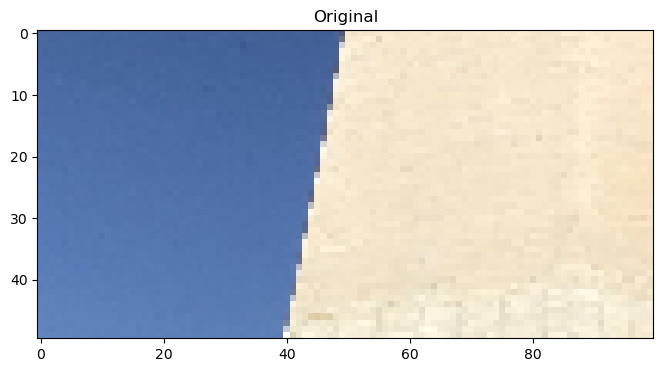

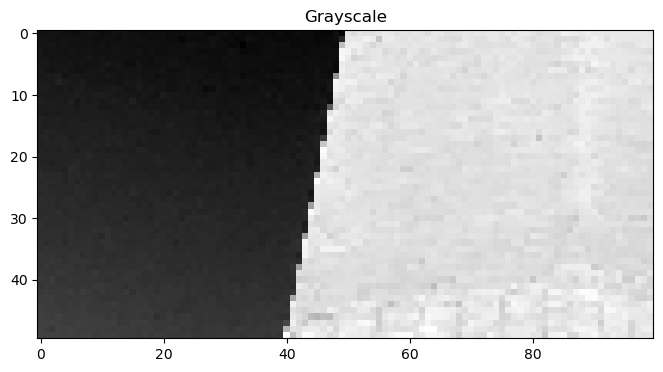

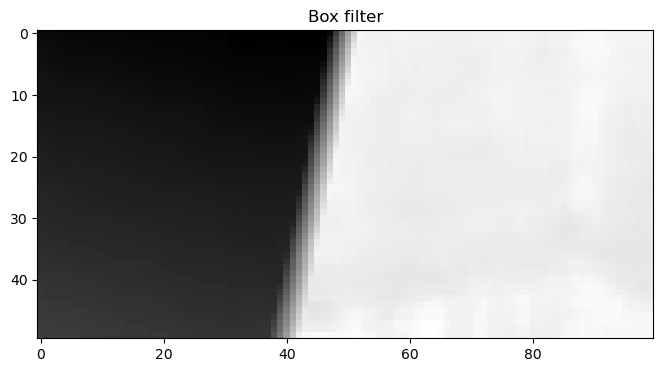

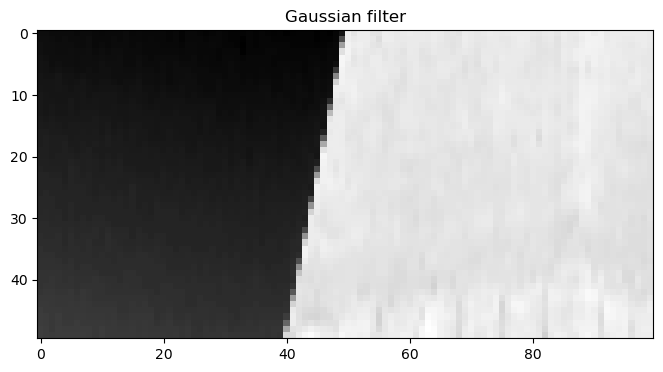

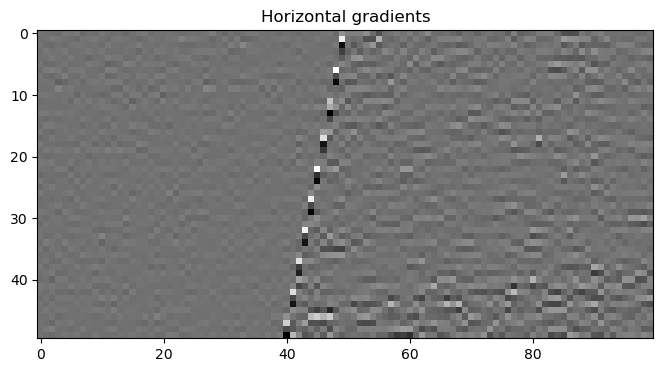

In [5]:
img = cv2.cvtColor(cv2.imread('img.jpg'), cv2.COLOR_BGR2RGB)

#img = cv2.resize(img, None, fx=0.5, fy=0.5)
img = cv2.resize(img, (480,256))
gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
kernel = np.ones((5,5),np.float32)/25 #creates 5,5 array filled with all 1s using 32 bit floats
#dividing by 25 in order to normalize, which ensures the filtered image maintains the same brightnesss and intensity as original
box = cv2.filter2D(gray,-1,kernel) #filter2d method convolves an image with the kernel, The function applies an arbitrary linear filter to an image.
kernel = cv2.getGaussianKernel(5,-1) #, takes in kernel size and sigma is standard deviation of gaussian dist, returns gaussiankernel coefficients
gauss = cv2.filter2D(gray,-1,kernel) #src as gray, -1 ddepth, using kernel as the kernel applied. gaussian blur (smooth/smoothing effect)
horiz = cv2.Sobel(gray, cv2.CV_32FC1, 0, 2, ksize=1) #sobel filter detects edges by computing spatial gradients (rate of change in pixel intensity)
#calcs derivates in x and/or y directions. CV_32FC1 is 32 bit float 1 channel output

irng = (slice(None), slice(None))
irng = (slice(100,150), slice(150,250))
plt.imshow(img[irng]), plt.title('Original'), plt.show();
plt.imshow(gray[irng], cmap='gray'), plt.title('Grayscale'), plt.show();
plt.imshow(box[irng], cmap='gray'), plt.title('Box filter'), plt.show();
plt.imshow(gauss[irng], cmap='gray'), plt.title('Gaussian filter'), plt.show();
plt.imshow(horiz[irng], cmap='gray'), plt.title('Horizontal gradients'), plt.show();

# Lab Objectives
The objectives of this lab are two-fold: re-inforce some of the objectives of the Spatial Filtering Module, and hands-on practice with Python, NumPy, and OpenCV. These are select module objectives:
- explain correlation and convolution, including their implementation and mathematical underpinnings
- explain the connection between edge detection and spatial gradients
- write down kernels for, Sobel, Harris and Prewitt edge detectors, box and sharpening filters
- calculate a Gaussian smoothing kernel of specified size
- discuss gradient thresholds and kernel size for edge detection
- explain edge detection with the Laplacian, including advantages and disadvantages, and the Laplacian of the Gaussian
- create Gaussian and Laplacian image pyramids

And the specific Python objectives:
- perform creatin and indexing of multi-dimensional NumPy arrays
- practice Python and NumPy coding 

Optional objectives:
- Apply Canny edge detection with `cv2.Canny`
- Morphological operations such as `cv2.erode` and `cv2.dilate`.
- Time the execution speed of you `myFilter2D` function with changing kernel sizes.

## Convolution and Correlation Lab
Submit this evaluated iPython Notebook.

1. Read the OpenCV documentation for `filter2D`. Calculate a horizontal Sobel gradient image from a gray-scale source image with correlation, and one with a convolution. Plot them both, side by side.

2. Create an ndarray of width $w$ that has one row of zeros, followed by one row of ones, followed by two rows of zeros, followed by two rows of ones, followed by three rows of zeros, and so on up to excluding $k$ rows of ones. You should probably take a look at the [NumPy Tutorial](https://numpy.org/doc/stable/user/quickstart.html) and the [NumPy Documentation](http://docs.scipy.org/doc/). Handy functions are `zeros`, `ones`, and `vstack`. Render this image with  
`
plt.imshow(img, cmap='gray', interpolation='none'), plt.title('Horizontal bars'), plt.show();
`
3. Create the coefficients for a Sobel filter. The `cv2.Sobel` function filters, but does not create an explicit kernel. To obtain the coefficients, you could filter a "1 impulse" image with this function to reconstruct the filter coefficients. Or you could use the [cv2.getDerivKernels](https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#ga6d6c23f7bd3f5836c31cfae994fc4aea) function to generate the coefficients.
4. Filter your stripe-image with cv2.Sobel. Change the Sobel filter's orientation and filter the original stripe image with that. Then filter the original stripes with the `getGaussianKernel` method. Then, filter your original strip image with the `cv2.Laplacian` method. Your submission must include a 2x2 grid of subplots with these four result images. Upload the output image here.
5. Create a Gaussian pyramid from a color image and render the output images. Take care to start with an image size that is evenly divisible as many times as your pyramid has levels. (Why?)
6. From the Gaussian pyramid, create a Laplacian pyramid. Optional: Render each level as on the [OpenCV Pyramids Tutorial](https://docs.opencv.org/4.7.0/dc/dff/tutorial_py_pyramids.html#gsc.tab=0) (you do not need to do any image blending).
7. Optional: Implement 2D filtering yourself: write a function `myFilter2D(img, kernel)` that *convolves* a grayscale image with an odd-sized kernel (1x1, 3x3, 5x5, 7x7 etc.). Please: ignore the image border, either by making the output image smaller or setting the entire output image to zero prior to calculating the dot products. Plot the result of your function next to the *convolution* result with `filter2D`. Look at the way to reshape an array, for example, flattening it with `ravel()`.

In [18]:
# Common ddepth values in OpenCV:
# -1            : Output image has same depth as input.
# cv2.CV_8U     : 8‑bit unsigned int (typical for most images).
# cv2.CV_16U    : 16‑bit unsigned int.
# cv2.CV_16S    : 16‑bit signed int (useful for filters like Sobel/Laplacian
#                 where values can go negative or exceed 255).
# cv2.CV_32F    : 32‑bit float (higher precision, continuous‑valued results).
# cv2.CV_64F    : 64‑bit float (double precision).
#
# Usage:
# The ddepth parameter in functions such as cv2.filter2D(), cv2.Sobel(),
# and cv2.Laplacian() determines the data type of the output image.
#
# Example:
# Using ddepth = -1 with an 8‑bit input forces the output to remain 8‑bit,
# which can truncate negative or large values produced by edge detectors.
# Using cv2.CV_16S or cv2.CV_32F preserves the full computed range.
# Afterward, convert back to 8‑bit for display with cv2.convertScaleAbs().

[[-1.]
 [ 0.]
 [ 1.]]
[[1.]
 [2.]
 [1.]]
kernel
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
cow grayscale image applying kernel via correlation 
[[  0.  10.   2. ...   8.  -6.   0.]
 [  0.  12.   3. ...   9.  -7.   0.]
 [  0.   6.   3. ...   4.  -5.   0.]
 ...
 [  0.  35.  19. ...  19. -13.   0.]
 [  0.  20.  10. ...  54.   0.   0.]
 [  0.  18.  -4. ...  78.  16.   0.]]
cow grayscale image applying kernel via convolution (should be neg) 
[[  0. -10.  -2. ...  -8.   6.   0.]
 [  0. -12.  -3. ...  -9.   7.   0.]
 [  0.  -6.  -3. ...  -4.   5.   0.]
 ...
 [  0. -35. -19. ... -19.  13.   0.]
 [  0. -20. -10. ... -54.   0.   0.]
 [  0. -18.   4. ... -78. -16.   0.]]


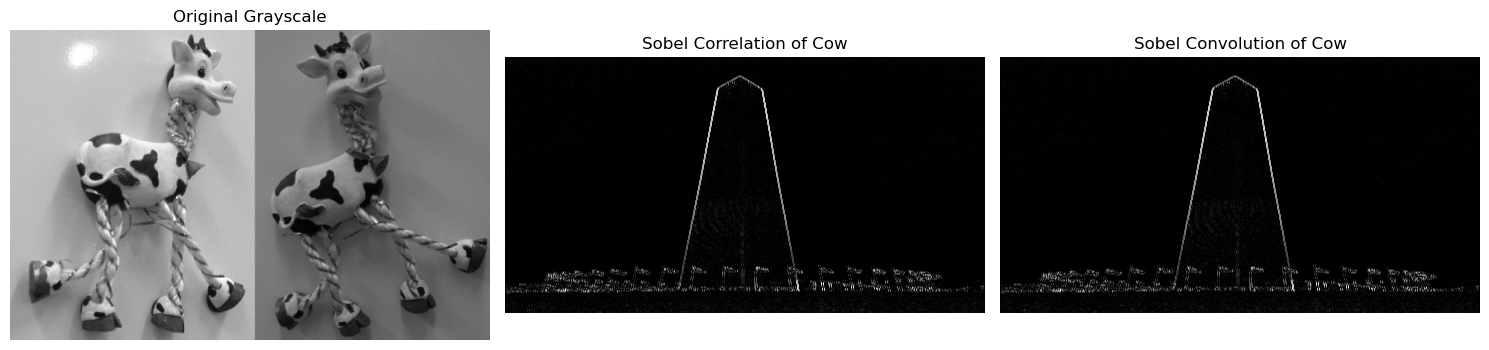

In [35]:
'''spatial filtering. looking at a pixela nd its neighbors and making a new picture based on that. you take image F (grid of numbers), a filter/kernel (H) (small grid of nums like 3x3), you multiply and add to get a result R
if you have a 3x3 filter you multiply each neighor by a number, add them all up, and that is you new pixel value '''

#1. calculate a horizontal sobel gradient image from gray-scale source image with correlation and one with a convolution 
#plot both side by side

cow_bgr = cv2.imread('cow.jpg', cv2.IMREAD_COLOR) #opencv -> bgr
cow_rgb = cv2.cvtColor(cow_bgr, cv2.COLOR_BGR2RGB) #bgr -> rgb
cow_gray = cv2.cvtColor(cow_rgb, cv2.COLOR_RGB2GRAY) #rgb -> gray
#use the gray source image and apply the sobel gradient, first we need a sobel kernel
#kernel emphasizes the right side minus the left side which shows vertical intensity changes
#1. get derivative coefficients
kx, ky = cv2.getDerivKernels(1,0,ksize=3)
print(kx)
print(ky)
#dx = 1, first derivative in x direction, no y derivative (just smoothing), 3x3 kernel
#doing dx=1 because we want the horizontal gradient to find the vertical edges

#3. dot product makes the 2d kernel
sobel_kernel = np.array([[-1, 0,  1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

print("kernel")
print(sobel_kernel)
#correlation - apply the kernel straight up, sliding filter normally across the image
cow_corr = cv2.filter2D(gray, cv2.CV_64F,kernel=sobel_kernel)
print(f'cow grayscale image applying kernel via correlation \n{cow_corr}')
#convolution - filter gets flipped before sliding
cow_conv = cv2.filter2D(gray, cv2.CV_64F, np.flip(sobel_kernel))
print(f'cow grayscale image applying kernel via convolution (should be neg) \n{cow_conv}')

#plot
figure, axes = plt.subplots(1,3, figsize=(15,5)) #figsize is w,h in inches

axes[0].imshow(cow_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(np.abs(cow_corr), cmap='gray')
axes[1].set_title('Sobel Correlation of Cow') #use absolute val bc edges can be pos/neg
axes[1].axis('off')

axes[2].imshow(np.abs(cow_conv), cmap='gray') #use absolute val bc edges can be pos/neg
axes[2].set_title('Sobel Convolution of Cow')
axes[2].axis('off')

plt.tight_layout()
plt.show()






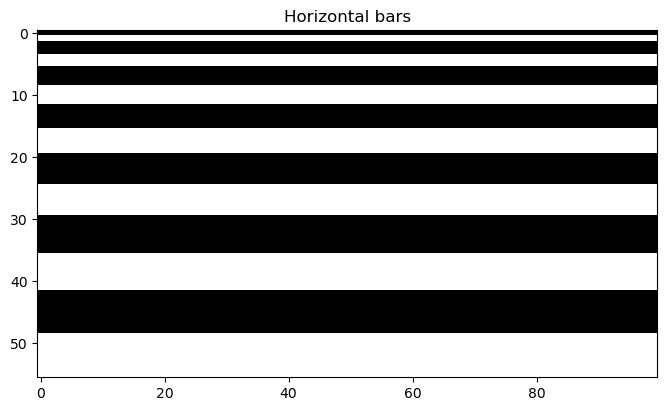

In [ ]:
'''2. Create an ndarray of width $w$ that has one row of zeros, followed by one row of ones, followed by two rows of zeros, 
followed by two rows of ones, followed by three rows of zeros, and so on up to excluding $k$ rows of ones. 
You should probably take a look at the [NumPy Tutorial](https://numpy.org/doc/stable/user/quickstart.html) and the 
[NumPy Documentation](http://docs.scipy.org/doc/). Handy functions are `zeros`, `ones`, and `vstack`. Render this image with 

000000
111111
000000
000000
111111
111111


plt.imshow(img, cmap='gray', interpolation='none'), plt.title('Horizontal bars'), plt.show();
'''
def alternating_zeros_and_ones_np_arr(w,k):
    rows = []
    for i in range (1,k): #repeat this population 7 times
        zeroes_rows = np.zeros((i,w))
        rows.append(zeroes_rows) #1x100 row inserted of zeros, then 2x100 etc each time 

        ones_rows = np.ones((i,w))
        rows.append(ones_rows)#1x100 row inserted of ones, now loop
    #stack it
    img = np.vstack(rows)
    return img

stripes = alternating_zeros_and_ones_np_arr(w=int(100),k=int(8))

plt.figure(figsize=(8,8))
plt.imshow(img, cmap='gray', interpolation='none'), plt.title('Horizontal bars'), plt.show();



In [56]:
'''3. Create the coefficients for a Sobel filter. The `cv2.Sobel` function filters, but does not create an explicit kernel.
 To obtain the coefficients, you could filter a "1 impulse" image with this function to reconstruct the filter coefficients. 
 Or you could use the [cv2.getDerivKernels](https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#ga6d6c23f7bd3f5836c31cfae994fc4aea) 
 function to generate the coefficients.'''
#lets try both methods
kx,ky = cv2.getDerivKernels(dx=1,dy=0,ksize=3) #first derivative to find the vertical edges, no deriv in y direction, ksize is 3x3 kernel
print(f'kx\n {kx}') #this is col, need 1xd
kx = kx.reshape(-1)
print(f'kx\n {kx}')
print(f'ky\n {ky}') #this is col, need 1xd
ky = ky.reshape(-1)
print(f'kx\n {kx}')
wrong_kernel = np.outer(kx,ky)
print(f'wrong kernel\n{wrong_kernel}')
sobel_kernel = np.outer(ky,kx)
print(f'right kernel: \n {sobel_kernel}')

#impulse
impulse = np.zeros((3,3))
impulse[1,1] = 1
result = cv2.Sobel(impulse,cv2.CV_64F,1,0,ksize=3)


kx
 [[-1.]
 [ 0.]
 [ 1.]]
kx
 [-1.  0.  1.]
ky
 [[1.]
 [2.]
 [1.]]
kx
 [-1.  0.  1.]
wrong kernel
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]
right kernel: 
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


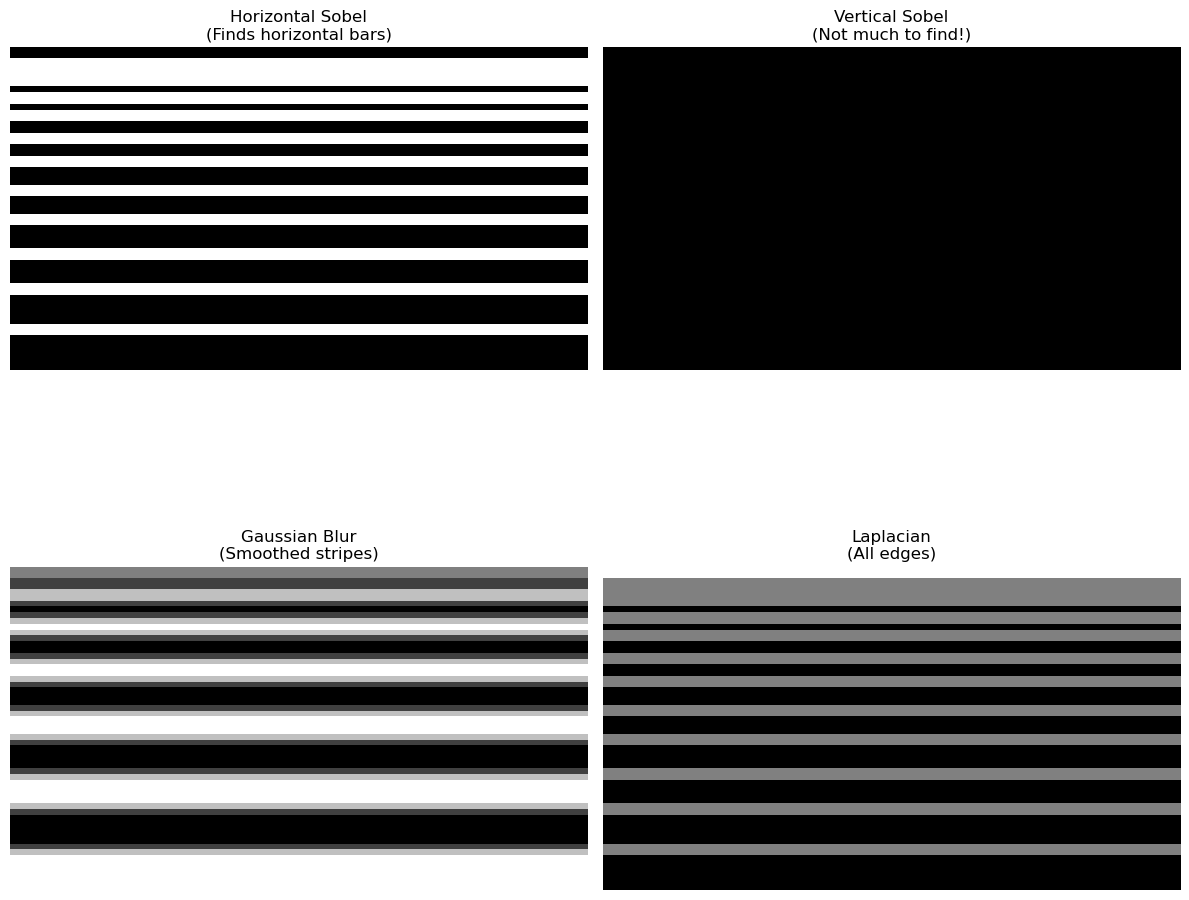

In [ ]:
'''4. Filter your stripe-image with cv2.Sobel. Change the Sobel filter's orientation and filter the original stripe image with that.
 Then filter the original stripes with the `getGaussianKernel` method. Then, filter your original strip image with the `cv2.Laplacian` method.
Your submission must include a 2x2 grid of subplots with these four result images. Upload the output image here.'''

stripes = alternating_zeros_and_ones_np_arr(100,8)

filtered_stripes_horizontal = cv2.Sobel(stripes,cv2.CV_64F,0,1,ksize=3) #finds horizontal edges
filtered_stripes_vertical = cv2.Sobel(stripes,cv2.CV_64F,1,0,ksize=3) #finds vert edges

gaussian_kernel = cv2.getGaussianKernel(3,-1) #std dev of -, should blur the image
gaussian_filter = cv2.filter2D(stripes,cv2.CV_64F,gaussian_kernel)

laplacian_filter = cv2.Laplacian(stripes,cv2.CV_64F) #The function calculates the Laplacian of the source image by adding up the second x and y derivatives calculated using the Sobel operator

fig,axes = plt.subplots(2,2,figsize=(12,12))

axes[0, 0].imshow(np.abs(filtered_stripes_horizontal), cmap='gray')
axes[0, 0].set_title('Horizontal Sobel\n(Finds horizontal bars)') 
axes[0, 0].axis('off')

#Top-right: Vertical Sobel
axes[0, 1].imshow(np.abs(filtered_stripes_vertical), cmap='gray')
axes[0, 1].set_title('Vertical Sobel\n)') #nothing bc all horizontal stripes
axes[0, 1].axis('off')

#Bottom-left: Gaussian
axes[1, 0].imshow(gaussian_filter, cmap='gray')
axes[1, 0].set_title('Gaussian Blur\n(Smoothed stripes)') #blurry stripes
axes[1, 0].axis('off')

#Bottom-right: Laplacian
axes[1, 1].imshow(np.abs(laplacian_filter), cmap='gray')
axes[1, 1].set_title('Laplacian\n(All edges)') #shows edges but more sensitive to noise
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

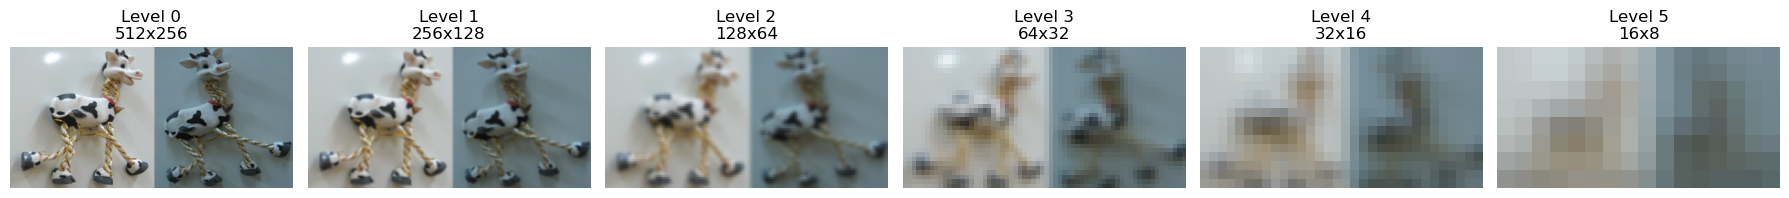

In [ ]:
'''5. Create a Gaussian pyramid from a color image and render the output images.
 Take care to start with an image size that is evenly divisible as many times as your pyramid has levels. (Why?)'''

#goal is to make the same picture smaller and smaller, each level is half the size of the previous one
#we blur before we shrik to avoid aliasing, which is weird patterns that emerge from downsampling
#need evenly divisible src image because each level divides dimensions by 2, can't have fractional pixels

def gauss_pyramid(src,levels=6):
    '''should return a list of images of halfed size'''
    
    #if dimensions are divisible by 2^(levels-1)
    height, width = src.shape[:2]
    divisor = 2 ** (levels - 1)  # For 6 levels, need divisible by 2^5 = 32
    
    if height % divisor != 0 or width % divisor != 0:
        #Calculate nearest valid dimensions
        new_width = (width // divisor) * divisor
        new_height = (height // divisor) * divisor
        raise ValueError(
            f"Image dimensions {width}x{height} are not evenly divisible by {divisor} for {levels} pyramid levels.\n"
            f"Resize image to dimensions divisible by {divisor}, such as {new_width}x{new_height}"
        )
    
    pyramid = [src] #will populate
    
    for i in range(0,levels-1):
        blurred_src = cv2.GaussianBlur(pyramid[i],(5,5),0) #sigma = 0.3*((ksize-1)*0.5 - 1) + 0.8
        shrunk = cv2.pyrDown(blurred_src) #blurs and downsamples the src image
        pyramid.append(shrunk)
    
    return pyramid

cow = cv2.imread('cow.jpg')
cow_rgb = cv2.cvtColor(cow,cv2.COLOR_BGR2RGB)
cow_resize_even = cv2.resize(cow_rgb,(512,256))

pyramid = gauss_pyramid(cow_resize_even,6)

#Create figure with subplots that visually show the shrinking
fig = plt.figure(figsize=(18, 6))

for i, level in enumerate(pyramid):
    # Create subplot with width proportional to image width to show actual shrinking
    #All images start from same vertical position but shrink horizontally
    ax = fig.add_subplot(1, len(pyramid), i+1)
    ax.imshow(level)
    ax.set_title(f'Level {i}\n{level.shape[1]}x{level.shape[0]}')
    ax.axis('off')
    
    #Set aspect ratio to show actual relative sizes
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

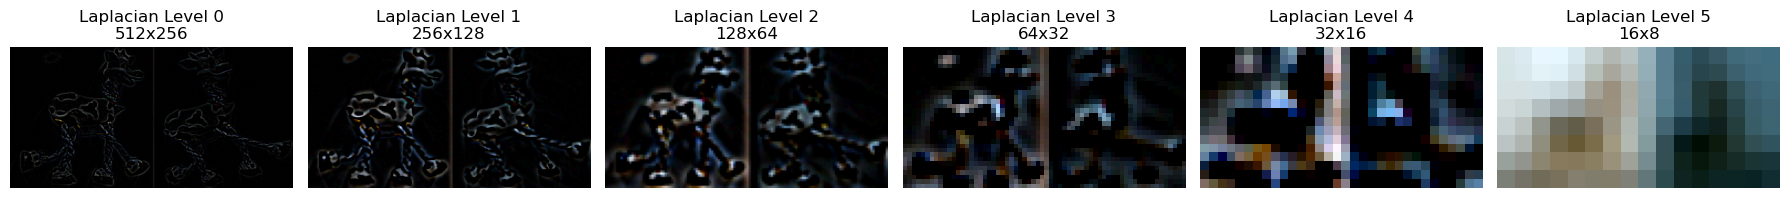

In [69]:
'''6. From the Gaussian pyramid, create a Laplacian pyramid.
Optional: Render each level as on the [OpenCV Pyramids Tutorial](https://docs.opencv.org/4.7.0/dc/dff/tutorial_py_pyramids.html#gsc.tab=0)
(you do not need to do any image blending).'''

#laplacian pyramid stores the difference between levels
#like asking what details did we lose going to the next level of pyramid
#formula = laplacian[level] = gaussian[level] - upscale(gaussian[level+1])

def create_laplacian_pyramid(gauss_pyramid):
    #input - list of images from gaussian pyramid
    #output- list of laplacian images
    laplacian_pyr = []
    for i in range(len(gauss_pyramid)-1):
        current_level = gauss_pyramid[i]
        next_level = gauss_pyramid[i+1]
        upscaled = cv2.pyrUp(next_level)
        if upscaled.shape != current_level.shape:
            upscaled = cv2.resize(upscaled,(current_level[1],current_level[0]))
        laplacian_img = cv2.subtract(current_level,upscaled)
        laplacian_pyr.append(laplacian_img)
    #at the end we are at the top of the pyramid so we just add the initial image since theres no comparison to do
    laplacian_pyr.append(gauss_pyramid[-1])
    return laplacian_pyr

laplacian_pyramid = create_laplacian_pyramid(pyramid)

fig = plt.figure(figsize=(18, 6))

for i, level in enumerate(laplacian_pyramid):
    ax = fig.add_subplot(1, len(laplacian_pyramid), i+1)
    
    #normalize for display (Laplacian can have negative values)
    #Convert to uint8 range [0, 255] for proper visualization
    display_img = cv2.normalize(level, None, 0, 255, cv2.NORM_MINMAX)
    display_img = display_img.astype(np.uint8)
    
    ax.imshow(display_img)
    ax.set_title(f'Laplacian Level {i}\n{level.shape[1]}x{level.shape[0]}')
    ax.axis('off')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
'''7. Optional: Implement 2D filtering yourself: write a function `myFilter2D(img, kernel)` that *convolves* a grayscale image with
an odd-sized kernel (1x1, 3x3, 5x5, 7x7 etc.). Please: ignore the image border, either by making the output image smaller or setting 
the entire output image to zero prior to calculating the dot products. 
Plot the result of your function next to the *convolution* result with `filter2D`. 
Look at the way to reshape an array, for example, flattening it with `ravel()`.'''

## Spatial Filtering Questions
Very concisely (short and to the point) answer the following questions.

1. Give two examples of non-linear spatial filters.

non-linar spatial filters are those that cannot be achieved by just multiplying/adding like in correlation/convolution.
Median Filter: replaces each pixel with median value of its neighborhood. 
Min/Max Filters: replaces each pixel with the min or max value in the neighborhood.

2. Can each of these non-linear filters be expressed as a convolution?
No, see above. Weighted sum operations are non-linear due to their need for comparison or sorting.

3. What is a bilinear kernel?
A filter that blends the 4 (L/R,U/D) nearest pixels, weighted by distance, to create new pixel values during image resizing with respective magnitude.

4. What does binomial refer to?
Binomial refers to spatial filter kernels derived from Pascal’s triangle, used as separable smoothing filters that approximate a Gaussian blur.

5. What is bicubic interpolation?
A spatial resampling filter that computes each output pixel from a weighted 4×4 neighborhood using cubic kernels.

6. What is aliasing? 
Distortion from downsizing an image, which can be countered by blurring before downsizing.

7. How are edges, curves, and lines related? 
Edges are detercted via derivate spatial filters; curves are connected edge responses; lines are straight, structured edge patterns.
